# Data Preparation
### DSCI 5260 — Group 6 | Medicare Inpatient Utilization and Payment Analysis

This notebook covers all data preparation steps documented in Section 3 of the Assignment 4 report:
- **3.1** Data Quality Assessment and Cleaning
- **3.2** Feature Engineering
- **3.3** Transformations and Normalization
- **3.4** Feature Selection
- **3.5** Data Splitting (70/15/15)
- **3.6** Final Dataset Export

> **Input:** `df_medidata` produced by `DataPreprocessing.ipynb`  
> **Output:** `df_medidata_clean` — fully prepared dataset ready for modeling

---
## 0. Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# ── Load the merged dataset from DataPreprocessing.ipynb ──
# If you saved df_medidata as a parquet or csv, load it here
# df_medidata = pd.read_parquet('../Data/df_medidata.parquet')
# df_medidata = pd.read_csv('../Data/df_medidata.csv')

import pandas as pd
from pathlib import Path

BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "Data" / "Processed_Data"

df_medidata = pd.read_parquet(PROCESSED_DIR / "df_medidata.parquet")

print("Loaded:", df_medidata.shape)
df_medidata.head()

print("Dataset shape:", df_medidata.shape)
print("Columns:", df_medidata.columns.tolist())

Loaded: (1178407, 20)
Dataset shape: (1178407, 20)
Columns: ['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_St', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA', 'Rndrng_Prvdr_RUCA_Desc', 'DRG_Cd', 'DRG_Desc', 'Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt', 'Data_Year', 'GNRL_CNTL_TYPE_CD', 'CRTFD_BED_CNT', 'BED_CNT', 'Ownership_Type', 'ownership_individual', 'DRG_Weight']


---
## 3.1 Data Quality Assessment and Cleaning

### 3.1.1 Missing Values

In [2]:
# ── Check missing values across all columns ──
missing = df_medidata.isnull().sum()
missing_pct = (missing / len(df_medidata) * 100).round(4)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

print("Columns with missing values:")
print(missing_summary)

Columns with missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [3]:
# ── Impute RUCA missing values ──
# Replace NaN RUCA with 99 (Unknown placeholder)
df_medidata['Rndrng_Prvdr_RUCA'] = df_medidata['Rndrng_Prvdr_RUCA'].fillna(99)
df_medidata['Rndrng_Prvdr_RUCA_Desc'] = df_medidata['Rndrng_Prvdr_RUCA_Desc'].fillna('Unknown')

print("RUCA Unknown records:", (df_medidata['Rndrng_Prvdr_RUCA'] == 99).sum())

RUCA Unknown records: 5739


In [4]:
# ── Confirm no missing values remain ──
total_missing = df_medidata.isnull().sum().sum()
print(f"Total missing values after imputation: {total_missing}")

Total missing values after imputation: 0


### 3.1.2 Duplicates and Structural Validation

In [5]:
# ── Validate primary key uniqueness ──
pk_cols = ['Rndrng_Prvdr_CCN', 'DRG_Cd', 'Data_Year']
duplicates = df_medidata.duplicated(subset=pk_cols).sum()
print(f"Duplicate records on primary key {pk_cols}: {duplicates}")

# ── Check total shape ──
print(f"Dataset shape: {df_medidata.shape}")

Duplicate records on primary key ['Rndrng_Prvdr_CCN', 'DRG_Cd', 'Data_Year']: 0
Dataset shape: (1178407, 20)


### DROP `Avg_Mdcr_Pymt_Amt` = 0 rows

In [6]:
# Check how many zero payment rows exist
zero_rows = df_medidata[df_medidata['Avg_Mdcr_Pymt_Amt'] == 0]
print(f'Zero payment rows: {len(zero_rows)}')
print(zero_rows[['Rndrng_Prvdr_CCN', 'DRG_Cd', 'Data_Year', 'Avg_Mdcr_Pymt_Amt']].head(10))

Zero payment rows: 2
        Rndrng_Prvdr_CCN  DRG_Cd  Data_Year  Avg_Mdcr_Pymt_Amt
342672            390049     642       2018                0.0
642684            210068     999       2020                0.0


In [7]:
df_medidata = df_medidata[df_medidata['Avg_Mdcr_Pymt_Amt'] != 0].reset_index(drop=True)

# Verify
print(f'Rows after dropping zeros: {len(df_medidata)}')
print(f'Zero payment rows remaining: {(df_medidata["Avg_Mdcr_Pymt_Amt"] == 0).sum()}')

Rows after dropping zeros: 1178405
Zero payment rows remaining: 0


### Data Cleaning — Zero Payment Rows

Two records with `Avg_Mdcr_Pymt_Amt = 0` were identified and removed prior to modeling.
Zero payment values are likely data entry errors or suppressed records, and would produce
undefined values under log transformation (log(0) = −∞). Removing these two rows has
negligible impact on a dataset of approximately 1.18 million records.

### 3.1.3 Outlier Treatment

In [8]:
# ── IQR-based outlier detection (identification only — not removed) ──
numeric_cols = ['Tot_Dschrgs', 'Avg_Submtd_Cvrd_Chrg', 'Avg_Mdcr_Pymt_Amt', 'BED_CNT', 'DRG_Weight']

outlier_summary = []
for col in numeric_cols:
    Q1 = df_medidata[col].quantile(0.25)
    Q3 = df_medidata[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_medidata[col] < lower) | (df_medidata[col] > upper)).sum()
    outlier_summary.append({'Column': col, 'Lower Fence': round(lower, 2),
                             'Upper Fence': round(upper, 2), 'Outlier Count': n_outliers,
                             'Outlier %': round(n_outliers / len(df_medidata) * 100, 2)})

print(pd.DataFrame(outlier_summary).to_string(index=False))
print("\nDecision: All outliers RETAINED — represent legitimate high-complexity hospitals and DRGs.")

              Column  Lower Fence  Upper Fence  Outlier Count  Outlier %
         Tot_Dschrgs       -20.50        71.50         108815       9.23
Avg_Submtd_Cvrd_Chrg    -57444.87    173013.70          94482       8.02
   Avg_Mdcr_Pymt_Amt     -7879.09     29052.84         109983       9.33
             BED_CNT      -335.50      1148.50          46900       3.98
          DRG_Weight        -0.78         3.79         121232      10.29

Decision: All outliers RETAINED — represent legitimate high-complexity hospitals and DRGs.


---
## 3.2 Feature Engineering

In [9]:
# ── Engineer Payment_Gap and Payment_Ratio ──
df_medidata['Payment_Gap'] = df_medidata['Avg_Submtd_Cvrd_Chrg'] - df_medidata['Avg_Mdcr_Pymt_Amt']
df_medidata['Payment_Ratio'] = df_medidata['Avg_Mdcr_Pymt_Amt'] / df_medidata['Avg_Submtd_Cvrd_Chrg']

# ── Normalized efficiency metrics ──
df_medidata['payment_gap_per_discharge'] = df_medidata['Payment_Gap'] / df_medidata['Tot_Dschrgs']
df_medidata['discharges_per_bed'] = np.where(
    df_medidata['BED_CNT'] > 0,
    df_medidata['Tot_Dschrgs'] / df_medidata['BED_CNT'],
    np.nan
)

# ── RUCA geographic grouping ──
def ruca_group(ruca):
    if ruca <= 3:   return 'Metropolitan'
    elif ruca <= 6: return 'Micropolitan'
    elif ruca <= 9: return 'Small Town'
    elif ruca <= 10: return 'Rural'
    else:           return 'Unknown'

df_medidata['RUCA_Group'] = df_medidata['Rndrng_Prvdr_RUCA'].apply(ruca_group)

print("New features added:")
new_cols = ['Payment_Gap', 'Payment_Ratio', 'payment_gap_per_discharge', 'discharges_per_bed', 'RUCA_Group']
print(df_medidata[new_cols].describe())

New features added:
        Payment_Gap  Payment_Ratio  payment_gap_per_discharge  \
count  1.178405e+06   1.178405e+06               1.178405e+06   
mean   6.152478e+04   2.287440e-01               3.079148e+03   
std    8.331034e+04   1.510001e-01               5.057885e+03   
min   -1.078771e+05   3.842061e-03              -9.535182e+03   
25%    2.158265e+04   1.401764e-01               7.285124e+02   
50%    3.870958e+04   1.956622e-01               1.635850e+03   
75%    7.153156e+04   2.673005e-01               3.525316e+03   
max    9.667454e+06   8.148943e+00               4.784214e+05   

       discharges_per_bed  
count        1.178405e+06  
mean         1.354943e-01  
std          4.291066e-01  
min          3.383574e-03  
25%          3.571429e-02  
50%          6.605505e-02  
75%          1.327014e-01  
max          9.733333e+01  


In [10]:
# ── Check for negative Payment_Gap values (Medicare cost-outlier payments) ──
print("Negative Payment_Gap:",        (df_medidata['Payment_Gap'] < 0).sum())
print("Negative gap_per_discharge:",  (df_medidata['payment_gap_per_discharge'] < 0).sum())
print("Payment_Ratio > 1:",           (df_medidata['Payment_Ratio'] > 1).sum())

# ── Engineer outlier_payment_flag for RQ5 ──
df_medidata['outlier_payment_flag'] = (df_medidata['Payment_Ratio'] > 1).astype(int)
print(f"\noutlier_payment_flag distribution:")
print(df_medidata['outlier_payment_flag'].value_counts())

Negative Payment_Gap: 1539
Negative gap_per_discharge: 1539
Payment_Ratio > 1: 1539

outlier_payment_flag distribution:
outlier_payment_flag
0    1176866
1       1539
Name: count, dtype: int64


> **outlier_payment_flag** — Binary indicator engineered from Payment_Ratio:
> - **0** = Standard record — Medicare paid less than the billed charge (normal, 1,176,868 records, 99.87%)
> - **1** = Cost-outlier payment — Medicare paid more than the billed charge due to CMS supplemental reimbursement policy (1,539 records, 0.13%)
>
> These 1,539 flagged records are **not data errors**. They represent legitimate Medicare cost-outlier cases and are retained in the dataset. This flag will be used as a pre-identified anomaly indicator in RQ5.

---
## 3.3 Transformations and Normalization

### 3.3.1 Log Transformation of Skewed Variables

- **Standard log1p** applied to always positive variables
- **Log-Modulus transformation**  applied to variables which could have negative values: `L(x) = sign(x) × log1p(|x|)`

In [11]:
# ── Standard log1p for always positive variables ──
df_medidata['Log_Avg_Submtd_Cvrd_Chrg'] = np.log1p(df_medidata['Avg_Submtd_Cvrd_Chrg'])
df_medidata['Log_Avg_Mdcr_Pymt_Amt']    = np.log1p(df_medidata['Avg_Mdcr_Pymt_Amt'])
df_medidata['Log_Tot_Dschrgs']           = np.log1p(df_medidata['Tot_Dschrgs'])

# ── Log-Modulus for signed variables (handles negatives safely) ──
df_medidata['Log_Payment_Gap'] = (
    np.sign(df_medidata['Payment_Gap']) * np.log1p(np.abs(df_medidata['Payment_Gap']))
)
df_medidata['Log_payment_gap_per_discharge'] = (
    np.sign(df_medidata['payment_gap_per_discharge']) *
    np.log1p(np.abs(df_medidata['payment_gap_per_discharge']))
)

print("Log-transformed columns created:")
log_cols = ['Log_Avg_Submtd_Cvrd_Chrg', 'Log_Avg_Mdcr_Pymt_Amt',
            'Log_Tot_Dschrgs', 'Log_Payment_Gap', 'Log_payment_gap_per_discharge']
print(df_medidata[log_cols].describe().round(3))

Log-transformed columns created:
       Log_Avg_Submtd_Cvrd_Chrg  Log_Avg_Mdcr_Pymt_Amt  Log_Tot_Dschrgs  \
count               1178405.000            1178405.000      1178405.000   
mean                     10.856                  9.228            3.268   
std                       0.813                  0.711            0.700   
min                       7.725                  4.897            2.485   
25%                      10.274                  8.695            2.708   
50%                      10.791                  9.139            3.091   
75%                      11.369                  9.629            3.638   
max                      16.159                 13.530            8.365   

       Log_Payment_Gap  Log_payment_gap_per_discharge  
count      1178405.000                    1178405.000  
mean            10.545                          7.334  
std              1.172                          1.296  
min            -11.589                         -9.163  
25%        

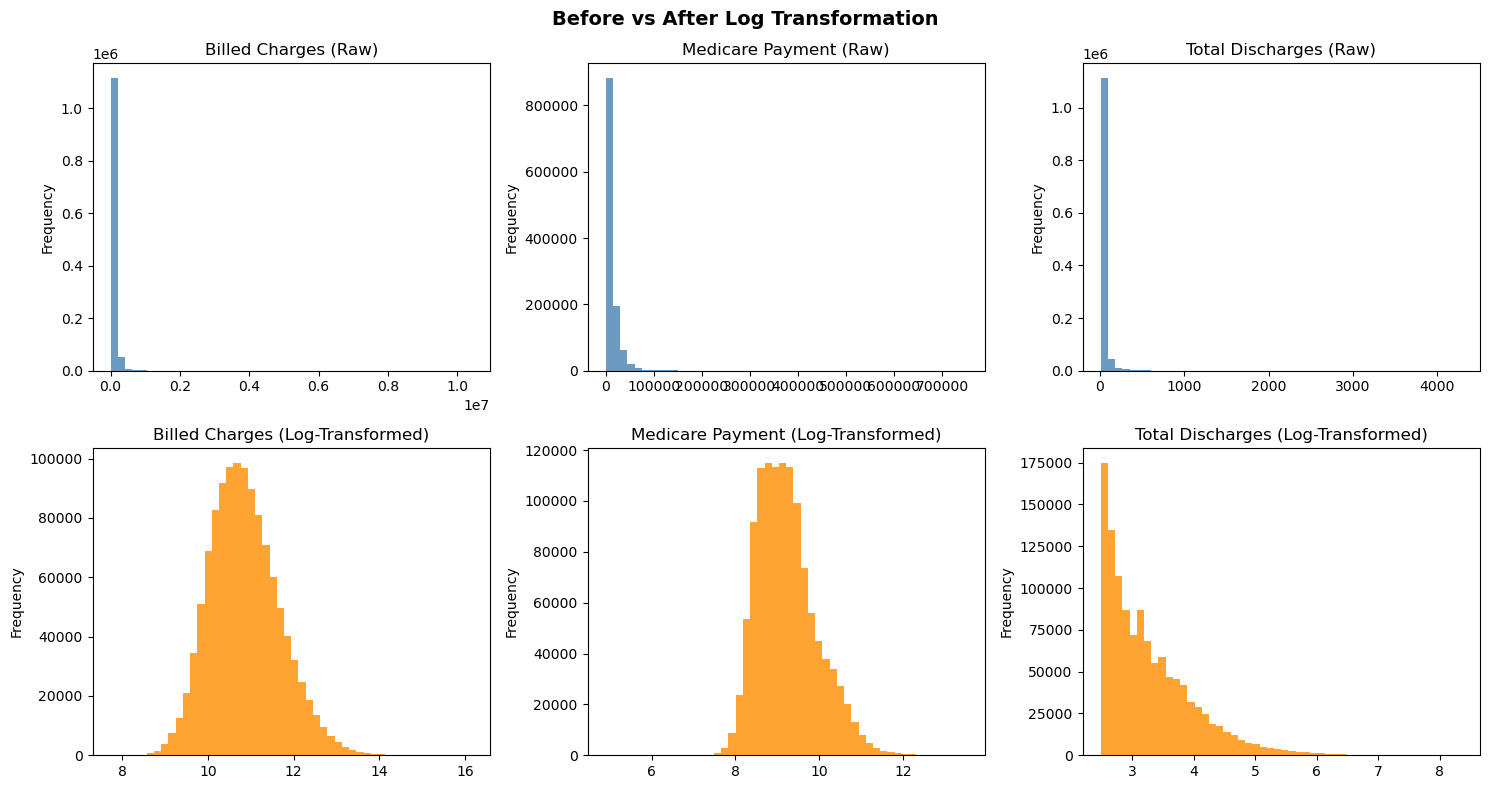

In [12]:
# ── Visual check: before vs after log transformation ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Before vs After Log Transformation', fontsize=14, fontweight='bold')

pairs = [
    ('Avg_Submtd_Cvrd_Chrg', 'Log_Avg_Submtd_Cvrd_Chrg', 'Billed Charges'),
    ('Avg_Mdcr_Pymt_Amt',    'Log_Avg_Mdcr_Pymt_Amt',    'Medicare Payment'),
    ('Tot_Dschrgs',          'Log_Tot_Dschrgs',           'Total Discharges'),
]

for i, (raw_col, log_col, title) in enumerate(pairs):
    axes[0, i].hist(df_medidata[raw_col], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[0, i].set_title(f'{title} (Raw)')
    axes[0, i].set_ylabel('Frequency')

    axes[1, i].hist(df_medidata[log_col], bins=50, color='darkorange', edgecolor='none', alpha=0.8)
    axes[1, i].set_title(f'{title} (Log-Transformed)')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
#plt.savefig('log_transform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3.2 Multicollinearity Reduction

In [13]:
# ── Drop redundant columns identified in EDA (r > 0.98) ──
# Avg_Tot_Pymt_Amt  dropped  → keep Avg_Mdcr_Pymt_Amt (r=0.98)
# CRTFD_BED_CNT     dropped  → keep BED_CNT            (r=0.99)

cols_to_drop = ['Avg_Tot_Pymt_Amt', 'CRTFD_BED_CNT']
df_medidata = df_medidata.drop(columns=cols_to_drop, errors='ignore')

print(f"Dropped: {cols_to_drop}")
print(f"Dataset shape after drop: {df_medidata.shape}")

Dropped: ['Avg_Tot_Pymt_Amt', 'CRTFD_BED_CNT']
Dataset shape after drop: (1178405, 29)


### 3.3.3 Categorical Encoding

#### One-hot encode ownership_category - For Profit, Government and Non - Profit

In [14]:
# ── One-hot encode ownership_category (3 classes) ──
ownership_dummies = pd.get_dummies(df_medidata['Ownership_Type'], prefix='own', drop_first=False)
df_medidata = pd.concat([df_medidata, ownership_dummies], axis=1)

print("Ownership dummy columns:", ownership_dummies.columns.tolist())
print(ownership_dummies.sum())

Ownership dummy columns: ['own_For-Profit', 'own_Government', 'own_Non-Profit']
own_For-Profit    856515
own_Government    118351
own_Non-Profit    203539
dtype: int64


#### One-hot encode RUCA_Group

In [15]:
# ── One-hot encode RUCA_Group (4 classes, excluding Unknown) ──
ruca_dummies = pd.get_dummies(
    df_medidata['RUCA_Group'].where(df_medidata['RUCA_Group'] != 'Unknown'),
    prefix='ruca', drop_first=False
)
df_medidata = pd.concat([df_medidata, ruca_dummies], axis=1)

print("RUCA dummy columns:", ruca_dummies.columns.tolist())
print(ruca_dummies.sum())

RUCA dummy columns: ['ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Rural', 'ruca_Small Town']
ruca_Metropolitan    1045267
ruca_Micropolitan     104963
ruca_Rural              3375
ruca_Small Town        18606
dtype: int64


---
## 3.4 Feature Selection Summary

In [16]:
# ── Define final modeling feature sets per RQ ──

# Features shared across all models
base_features = [
    'DRG_Weight',
    'Log_Tot_Dschrgs',
    'BED_CNT',
    'Data_Year',
    'own_For-Profit', 'own_Non-Profit', 'own_Government',
    'ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Small Town', 'ruca_Rural',
    'outlier_payment_flag'
]

# RQ1 — Payment Gap Analysis (descriptive, no model target here)
rq1_cols = base_features + ['Payment_Gap', 'Payment_Ratio', 'Log_Payment_Gap']

# RQ2 — Demand Forecasting target: Tot_Dschrgs
rq2_features = [f for f in base_features if f != 'Log_Tot_Dschrgs']
rq2_target   = 'Log_Tot_Dschrgs'

# RQ3 — Medicare Reimbursement Prediction target: Avg_Mdcr_Pymt_Amt
rq3_features = base_features + ['Log_Avg_Submtd_Cvrd_Chrg']
rq3_target   = 'Log_Avg_Mdcr_Pymt_Amt'

# RQ5 — Anomaly Detection target: outlier_payment_flag
rq5_features = base_features + ['Log_Avg_Submtd_Cvrd_Chrg', 'Log_Avg_Mdcr_Pymt_Amt', 'Log_Payment_Gap']
rq5_target   = 'outlier_payment_flag'

print("RQ2 features:", rq2_features)
print("\nRQ3 features:", rq3_features)
print("\nRQ5 features:", rq5_features)

RQ2 features: ['DRG_Weight', 'BED_CNT', 'Data_Year', 'own_For-Profit', 'own_Non-Profit', 'own_Government', 'ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Small Town', 'ruca_Rural', 'outlier_payment_flag']

RQ3 features: ['DRG_Weight', 'Log_Tot_Dschrgs', 'BED_CNT', 'Data_Year', 'own_For-Profit', 'own_Non-Profit', 'own_Government', 'ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Small Town', 'ruca_Rural', 'outlier_payment_flag', 'Log_Avg_Submtd_Cvrd_Chrg']

RQ5 features: ['DRG_Weight', 'Log_Tot_Dschrgs', 'BED_CNT', 'Data_Year', 'own_For-Profit', 'own_Non-Profit', 'own_Government', 'ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Small Town', 'ruca_Rural', 'outlier_payment_flag', 'Log_Avg_Submtd_Cvrd_Chrg', 'Log_Avg_Mdcr_Pymt_Amt', 'Log_Payment_Gap']


---
## 3.5 Data Splitting (70 / 15 / 15)

## How the Split is Done

- Start with **1,172,668 records** (5,739 Unknown RUCA removed before splitting)
- Create a stratification key: `ownership_category + RUCA_Group` (e.g. `For-Profit_Metropolitan`)
- **Step 1** — split 15% out as test → leaves 85% as train+val
- **Step 2** — split 15% out of the remaining 85% as validation → leaves 70% as train
- `random_state=42` ensures the same split every time the code is run
- Unknown RUCA records (5,739) are held out separately and not included in any split

In [17]:
# ── Stratified split on ownership_category and RUCA_Group ──
# Create a combined stratification key
df_medidata['strat_key'] = df_medidata['Ownership_Type'] + '_' + df_medidata['RUCA_Group']

# Remove Unknown RUCA from stratification key
df_split = df_medidata[df_medidata['RUCA_Group'] != 'Unknown'].copy()
df_unknown = df_medidata[df_medidata['RUCA_Group'] == 'Unknown'].copy()

# Step 1: Split off test (15%)
df_trainval, df_test = train_test_split(
    df_split, test_size=0.15,
    stratify=df_split['strat_key'],
    random_state=42
)

# Step 2: Split train/val from remaining 85% → 70% train, 15% val
df_train, df_val = train_test_split(
    df_trainval, test_size=(0.15 / 0.85),
    stratify=df_trainval['strat_key'],
    random_state=42
)

print(f"Train:      {len(df_train):>8,}  ({len(df_train)/len(df_split)*100:.1f}%)")
print(f"Validation: {len(df_val):>8,}  ({len(df_val)/len(df_split)*100:.1f}%)")
print(f"Test:       {len(df_test):>8,}  ({len(df_test)/len(df_split)*100:.1f}%)")
print(f"Unknown RUCA (held out): {len(df_unknown):,}")

Train:       820,547  (70.0%)
Validation:  175,832  (15.0%)
Test:        175,832  (15.0%)
Unknown RUCA (held out): 6,194


In [18]:
# ── Verify ownership distribution is preserved across splits ──
for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = split_df['Ownership_Type'].value_counts(normalize=True).round(3)
    print(f"{split_name}: {dist.to_dict()}")

Train: {'For-Profit': 0.727, 'Non-Profit': 0.173, 'Government': 0.1}
Val: {'For-Profit': 0.727, 'Non-Profit': 0.173, 'Government': 0.1}
Test: {'For-Profit': 0.727, 'Non-Profit': 0.173, 'Government': 0.1}


In [19]:
# ── Verify RUCA distribution is preserved across splits ──
for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    dist = split_df['RUCA_Group'].value_counts(normalize=True).round(3)
    print(f"{split_name}: {dist.to_dict()}")

Train: {'Metropolitan': 0.892, 'Micropolitan': 0.09, 'Small Town': 0.016, 'Rural': 0.003}
Val: {'Metropolitan': 0.892, 'Micropolitan': 0.09, 'Small Town': 0.016, 'Rural': 0.003}
Test: {'Metropolitan': 0.892, 'Micropolitan': 0.09, 'Small Town': 0.016, 'Rural': 0.003}


---
## 3.6 Final Dataset Description

In [20]:
# ── Clean up helper columns ──
df_medidata_clean = df_medidata.drop(columns=['strat_key'], errors='ignore')

print("=" * 50)
print("FINAL DATASET SUMMARY")
print("=" * 50)
print(f"Rows:             {df_medidata_clean.shape[0]:,}")
print(f"Columns:          {df_medidata_clean.shape[1]}")
print(f"Missing Values:   {df_medidata_clean.isnull().sum().sum()}")
print(f"Temporal Range:   2017 – 2023")
print(f"Primary Key:      (Rndrng_Prvdr_CCN, DRG_Cd, Data_Year)")
print()
print("Engineered features added:")
engineered = ['Payment_Gap', 'Payment_Ratio', 'payment_gap_per_discharge',
              'discharges_per_bed', 'RUCA_Group', 'outlier_payment_flag',
              'Log_Avg_Submtd_Cvrd_Chrg', 'Log_Avg_Mdcr_Pymt_Amt',
              'Log_Tot_Dschrgs', 'Log_Payment_Gap', 'Log_payment_gap_per_discharge']
for col in engineered:
    print(f"  + {col}")
print()
print("Columns dropped (multicollinearity):")
print("  - Avg_Tot_Pymt_Amt   (r=0.98 with Avg_Mdcr_Pymt_Amt)")
print("  - CRTFD_BED_CNT      (r=0.99 with BED_CNT)")

FINAL DATASET SUMMARY
Rows:             1,178,405
Columns:          36
Missing Values:   0
Temporal Range:   2017 – 2023
Primary Key:      (Rndrng_Prvdr_CCN, DRG_Cd, Data_Year)

Engineered features added:
  + Payment_Gap
  + Payment_Ratio
  + payment_gap_per_discharge
  + discharges_per_bed
  + RUCA_Group
  + outlier_payment_flag
  + Log_Avg_Submtd_Cvrd_Chrg
  + Log_Avg_Mdcr_Pymt_Amt
  + Log_Tot_Dschrgs
  + Log_Payment_Gap
  + Log_payment_gap_per_discharge

Columns dropped (multicollinearity):
  - Avg_Tot_Pymt_Amt   (r=0.98 with Avg_Mdcr_Pymt_Amt)
  - CRTFD_BED_CNT      (r=0.99 with BED_CNT)


In [21]:
df_medidata_clean.columns

Index(['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_City',
       'Rndrng_Prvdr_St', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA',
       'Rndrng_Prvdr_RUCA_Desc', 'DRG_Cd', 'DRG_Desc', 'Tot_Dschrgs',
       'Avg_Submtd_Cvrd_Chrg', 'Avg_Mdcr_Pymt_Amt', 'Data_Year',
       'GNRL_CNTL_TYPE_CD', 'BED_CNT', 'Ownership_Type',
       'ownership_individual', 'DRG_Weight', 'Payment_Gap', 'Payment_Ratio',
       'payment_gap_per_discharge', 'discharges_per_bed', 'RUCA_Group',
       'outlier_payment_flag', 'Log_Avg_Submtd_Cvrd_Chrg',
       'Log_Avg_Mdcr_Pymt_Amt', 'Log_Tot_Dschrgs', 'Log_Payment_Gap',
       'Log_payment_gap_per_discharge', 'own_For-Profit', 'own_Government',
       'own_Non-Profit', 'ruca_Metropolitan', 'ruca_Micropolitan',
       'ruca_Rural', 'ruca_Small Town'],
      dtype='object')

In [22]:
# ── Save final dataset and splits ──
DATA_PATH = "../Data/PROCESSED_DIR"
PROCESSED_DIR = Path('..') / 'Data' / 'Processed_Data'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_medidata_clean.to_parquet(PROCESSED_DIR / 'df_medidata_clean.parquet', index=False)
df_train.to_parquet(PROCESSED_DIR / 'df_train.parquet', index=False)
df_val.to_parquet(PROCESSED_DIR / 'df_val.parquet', index=False)
df_test.to_parquet(PROCESSED_DIR / 'df_test.parquet', index=False)

print("Saved:")
print("  df_medidata_clean.parquet")
print("  df_train.parquet")
print("  df_val.parquet")
print("  df_test.parquet")

Saved:
  df_medidata_clean.parquet
  df_train.parquet
  df_val.parquet
  df_test.parquet


In [23]:
# # ── Save cleaned dataset as Excel to Processed_Data folder ────────────────
# from pathlib import Path
# import pandas as pd

# PROCESSED_DIR = Path('..') / 'Data' / 'Processed_Data'
# PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# output_path = PROCESSED_DIR / 'df_medidata_cleaned.csv'

# print(f'Saving {df_medidata_clean.shape[0]:,} rows × {df_medidata_clean.shape[1]} columns...')
# df_medidata_clean.to_csv(output_path, index=False)
# print(f'Saved to: {output_path}')